# RETAIL SALES EDA PROJECT 

## Relevant Libraries Importation and Raw Data Loading

In [1]:
#Import Relevant Packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading Raw DataSet
raw_csv_data = pd.read_csv("retail_sales_raw.csv")
raw_data = raw_csv_data.copy()

# Basic Data Overview

In [3]:
raw_data.head()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount,Region,PaymentMethod,InvoiceDate
0,10000,1102,319,3,100.90,0.25,Kano,Card,2023-06-02
1,10001,1435,325,9,134.57,0.27,Abuja,Card,2023-07-21
2,10002,1860,254,1,258.73,0.06,Port Harcourt,POS,2023-11-17
3,10003,1270,226,5,168.65,0.19,Port Harcourt,Transfer,2024-04-08
4,10004,1106,317,2,430.95,0.28,NaN,Card,2023-01-11


In [4]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  5050 non-null   int64  
 1   CustomerID     5050 non-null   int64  
 2   ProductID      5050 non-null   int64  
 3   Quantity       5050 non-null   int64  
 4   UnitPrice      4950 non-null   float64
 5   Discount       5050 non-null   float64
 6   Region         3936 non-null   object 
 7   PaymentMethod  4008 non-null   object 
 8   InvoiceDate    5050 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 355.2+ KB


In [5]:
raw_data.describe()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount
count,5050.000000,5050.000000,5050.000000,5050.000000,4950.000000,5050.000000
mean,12499.514257,1505.389901,300.616832,5.002574,252.890855,0.152315
std,1442.142588,290.669438,57.570375,2.598084,143.730304,0.086309
min,10000.000000,1000.000000,200.000000,1.000000,5.080000,0.000000
25%,11252.250000,1253.000000,252.000000,3.000000,127.342500,0.080000
50%,12499.500000,1510.000000,300.000000,5.000000,250.315000,0.150000
75%,13747.750000,1760.000000,351.000000,7.000000,380.597500,0.230000
max,14999.000000,1999.000000,399.000000,9.000000,499.900000,0.300000


In [6]:
raw_data.head()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount,Region,PaymentMethod,InvoiceDate
0,10000,1102,319,3,100.90,0.25,Kano,Card,2023-06-02
1,10001,1435,325,9,134.57,0.27,Abuja,Card,2023-07-21
2,10002,1860,254,1,258.73,0.06,Port Harcourt,POS,2023-11-17
3,10003,1270,226,5,168.65,0.19,Port Harcourt,Transfer,2024-04-08
4,10004,1106,317,2,430.95,0.28,NaN,Card,2023-01-11


# Conversion of Date column

In [7]:
raw_data["InvoiceDate"] = pd.to_datetime(raw_data["InvoiceDate"])

In [8]:
raw_data["Year"] = raw_data["InvoiceDate"].dt.year
raw_data["Month"] = raw_data["InvoiceDate"].dt.month
raw_data["Weekday"] = raw_data["InvoiceDate"].dt.day_name()

In [9]:
raw_data.head()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount,Region,PaymentMethod,InvoiceDate,Year,Month,Weekday
0,10000,1102,319,3,100.90,0.25,Kano,Card,2023-06-02,2023,6,Friday
1,10001,1435,325,9,134.57,0.27,Abuja,Card,2023-07-21,2023,7,Friday
2,10002,1860,254,1,258.73,0.06,Port Harcourt,POS,2023-11-17,2023,11,Friday
3,10003,1270,226,5,168.65,0.19,Port Harcourt,Transfer,2024-04-08,2024,4,Monday
4,10004,1106,317,2,430.95,0.28,NaN,Card,2023-01-11,2023,1,Wednesday


In [10]:
updated_data=raw_data.copy()

## Fixing missing values and duplicates

In [11]:
updated_data.isnull().sum()

TransactionID       0
CustomerID          0
ProductID           0
Quantity            0
UnitPrice         100
Discount            0
Region           1114
PaymentMethod    1042
InvoiceDate         0
Year                0
Month               0
Weekday             0
dtype: int64

In [12]:
updated_data["UnitPrice"].fillna(updated_data['UnitPrice'].median(), inplace=True)   

In [13]:
updated_data["Region"].fillna(updated_data['Region'].mode()[0], inplace=True)   

In [14]:
updated_data["PaymentMethod"].fillna(updated_data['PaymentMethod'].mode()[0], inplace=True) 

In [15]:
updated_data.duplicated().sum()

48

In [16]:
updated_data = updated_data.drop_duplicates()

In [17]:
updated_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5002 entries, 0 to 5046
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  5002 non-null   int64         
 1   CustomerID     5002 non-null   int64         
 2   ProductID      5002 non-null   int64         
 3   Quantity       5002 non-null   int64         
 4   UnitPrice      5002 non-null   float64       
 5   Discount       5002 non-null   float64       
 6   Region         5002 non-null   object        
 7   PaymentMethod  5002 non-null   object        
 8   InvoiceDate    5002 non-null   datetime64[ns]
 9   Year           5002 non-null   int64         
 10  Month          5002 non-null   int64         
 11  Weekday        5002 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 508.0+ KB


## Feature Engineering

In [18]:
updated_data["TotalSales"] = updated_data["Quantity"] * updated_data["UnitPrice"]-(updated_data["Quantity"] * updated_data["UnitPrice"] * updated_data["Discount"])

In [19]:
#Average price after discount
updated_data["EffectivePrice"] = updated_data["UnitPrice"] * (1 - updated_data["Discount"])

In [20]:
updated_data.head()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount,Region,PaymentMethod,InvoiceDate,Year,Month,Weekday,TotalSales,EffectivePrice
0,10000,1102,319,3,100.90,0.25,Kano,Card,2023-06-02,2023,6,Friday,227.0250,75.6750
1,10001,1435,325,9,134.57,0.27,Abuja,Card,2023-07-21,2023,7,Friday,884.1249,98.2361
2,10002,1860,254,1,258.73,0.06,Port Harcourt,POS,2023-11-17,2023,11,Friday,243.2062,243.2062
3,10003,1270,226,5,168.65,0.19,Port Harcourt,Transfer,2024-04-08,2024,4,Monday,683.0325,136.6065
4,10004,1106,317,2,430.95,0.28,Port Harcourt,Card,2023-01-11,2023,1,Wednesday,620.5680,310.2840


# Outlier Detection

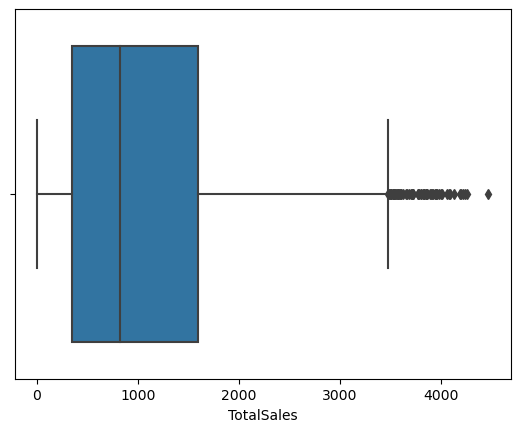

In [21]:
sns.boxplot(x=updated_data["TotalSales"])
plt.show()

In [22]:
Q1 = updated_data["TotalSales"].quantile(0.25)
Q3 = updated_data["TotalSales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

updated_data = updated_data[(updated_data["TotalSales"] >= lower) & (updated_data["TotalSales"] <= upper)]

In [23]:
updated_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4938 entries, 0 to 5046
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   TransactionID   4938 non-null   int64         
 1   CustomerID      4938 non-null   int64         
 2   ProductID       4938 non-null   int64         
 3   Quantity        4938 non-null   int64         
 4   UnitPrice       4938 non-null   float64       
 5   Discount        4938 non-null   float64       
 6   Region          4938 non-null   object        
 7   PaymentMethod   4938 non-null   object        
 8   InvoiceDate     4938 non-null   datetime64[ns]
 9   Year            4938 non-null   int64         
 10  Month           4938 non-null   int64         
 11  Weekday         4938 non-null   object        
 12  TotalSales      4938 non-null   float64       
 13  EffectivePrice  4938 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(6), object(3)
me

# Univariate Analysis

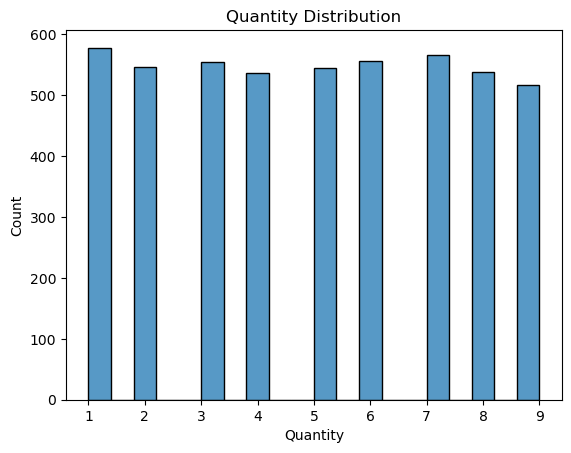

In [24]:
sns.histplot(updated_data["Quantity"], bins=20)
plt.title("Quantity Distribution")
plt.show()

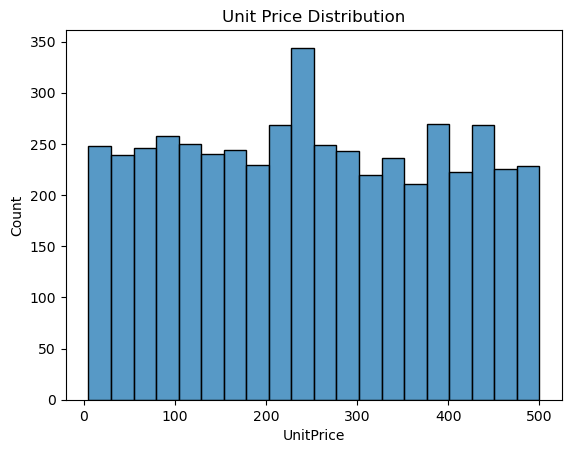

In [25]:
sns.histplot(updated_data["UnitPrice"], bins=20)
plt.title("Unit Price Distribution")
plt.show()

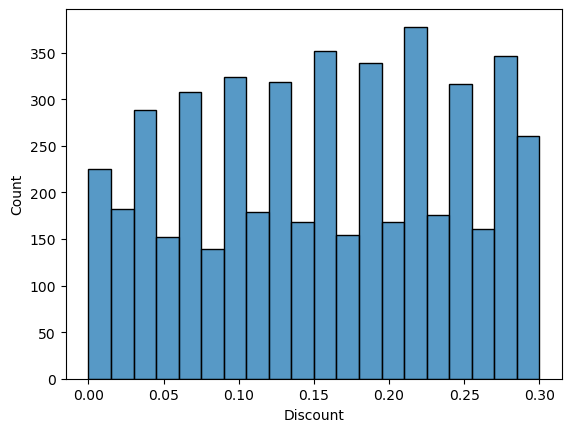

In [26]:
sns.histplot(updated_data["Discount"], bins=20)
plt.show()

# Sales Analysis

In [27]:
updated_data["TotalSales"].sum()

5121515.4792

In [28]:
# Average Order
updated_data["TotalSales"].mean()

1037.1639285540707

# Regional Sales Analysis

In [29]:
region_sales = updated_data.groupby("Region")["TotalSales"].sum().sort_values(ascending=False)

region_sales

Region
Port Harcourt    2.206349e+06
Abuja            1.016012e+06
Kano             9.586636e+05
Lagos            9.404904e+05
Name: TotalSales, dtype: float64

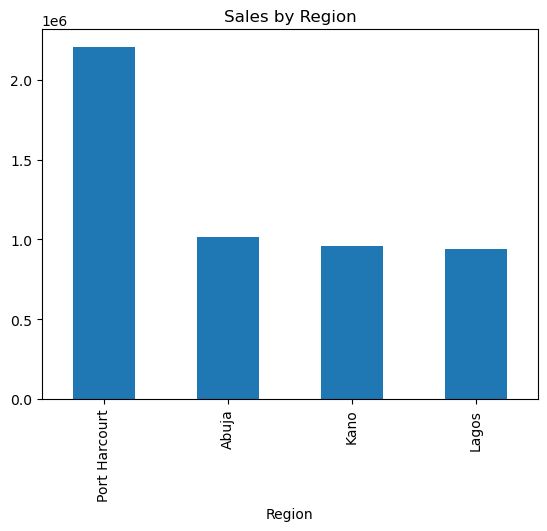

In [30]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

# Payment Method Analysis

In [31]:
updated_data["PaymentMethod"].value_counts()

Cash        2028
Transfer    1002
Card         957
POS          951
Name: PaymentMethod, dtype: int64

# Monthly Sales Trend

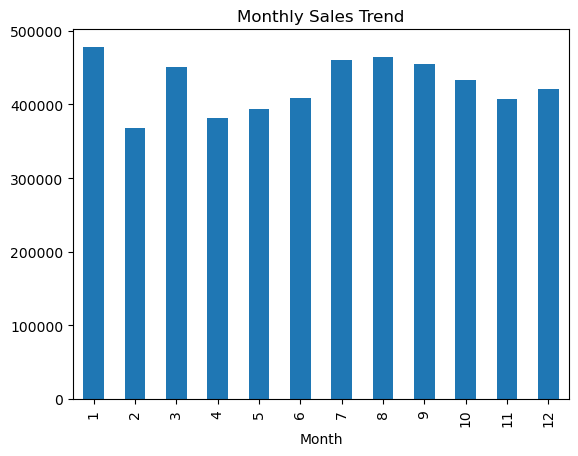

In [32]:
monthly_sales = updated_data.groupby("Month")["TotalSales"].sum()

monthly_sales.plot(kind="bar")
plt.title("Monthly Sales Trend")
plt.show()

In [33]:
average_monthly_sales=monthly_sales.mean()

In [34]:
average_monthly_sales

426792.9566

In [35]:
monthly_sales

Month
1     478139.15845
2     368437.24850
3     450552.87395
4     381932.43710
5     393291.05905
6     408456.47390
7     460073.03320
8     465030.48565
9     455174.65375
10    432957.15330
11    406964.30200
12    420506.60035
Name: TotalSales, dtype: float64

In [36]:
updated_data.head()

,TransactionID,CustomerID,ProductID,Quantity,UnitPrice,Discount,Region,PaymentMethod,InvoiceDate,Year,Month,Weekday,TotalSales,EffectivePrice
0,10000,1102,319,3,100.90,0.25,Kano,Card,2023-06-02,2023,6,Friday,227.0250,75.6750
1,10001,1435,325,9,134.57,0.27,Abuja,Card,2023-07-21,2023,7,Friday,884.1249,98.2361
2,10002,1860,254,1,258.73,0.06,Port Harcourt,POS,2023-11-17,2023,11,Friday,243.2062,243.2062
3,10003,1270,226,5,168.65,0.19,Port Harcourt,Transfer,2024-04-08,2024,4,Monday,683.0325,136.6065
4,10004,1106,317,2,430.95,0.28,Port Harcourt,Card,2023-01-11,2023,1,Wednesday,620.5680,310.2840


## Product Sales Per Customer & Region Analysis

In [37]:
product_region_sales = updated_data.groupby(['ProductID','Region'])['Quantity'].sum()
print(product_region_sales)

ProductID  Region       
200        Abuja             7
           Kano             23
           Lagos            30
           Port Harcourt    22
201        Abuja            19
                            ..
398        Port Harcourt    16
399        Abuja            27
           Kano             31
           Lagos             7
           Port Harcourt    53
Name: Quantity, Length: 792, dtype: int64


In [38]:
pivot_table = updated_data.pivot_table(values='Quantity',
                             index='ProductID',
                             columns='Region',
                             aggfunc='sum')

print(pivot_table)

Region     Abuja  Kano  Lagos  Port Harcourt
ProductID                                   
200          7.0  23.0   30.0           22.0
201         19.0  18.0   13.0           63.0
202          4.0  17.0   35.0           35.0
203         40.0  41.0   24.0           38.0
204         11.0   9.0   16.0           12.0
...          ...   ...    ...            ...
395          6.0  10.0   24.0           47.0
396         38.0  10.0   26.0           66.0
397          9.0   6.0    2.0           51.0
398         18.0  16.0   43.0           16.0
399         27.0  31.0    7.0           53.0

[200 rows x 4 columns]


In [39]:
top_region_product = pivot_table.idxmax(axis=1)
print(top_region_product)

ProductID
200            Lagos
201    Port Harcourt
202            Lagos
203             Kano
204            Lagos
           ...      
395    Port Harcourt
396    Port Harcourt
397    Port Harcourt
398            Lagos
399    Port Harcourt
Length: 200, dtype: object


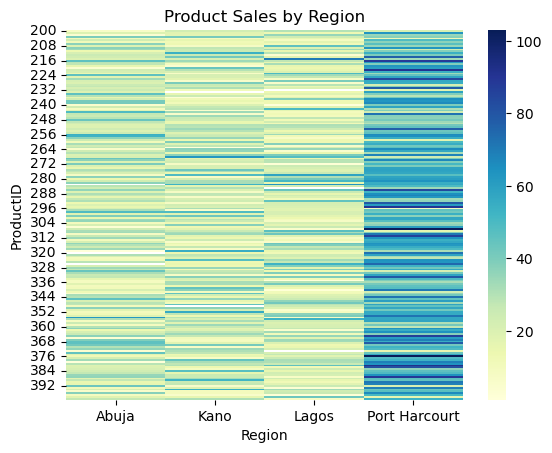

In [40]:
sns.heatmap(pivot_table, cmap="YlGnBu")
plt.title("Product Sales by Region")
plt.show()

In [41]:
#Product performance
product_sales = updated_data.groupby("ProductID")["TotalSales"].sum().sort_values(ascending=False)
product_sales

ProductID
365    53790.97210
216    41222.04920
283    40143.02820
367    39652.63025
286    39215.48920
          ...     
341    11668.23570
240    10972.72910
204     9410.95010
335     8627.48035
373     7999.86240
Name: TotalSales, Length: 200, dtype: float64

In [42]:
#Customer spending
customer_sales = updated_data.groupby("CustomerID")["TotalSales"].sum().sort_values(ascending=False)
customer_sales

CustomerID
1038    17333.51130
1735    17204.44220
1276    16833.13880
1935    15981.33970
1516    15776.97665
           ...     
1964      181.44000
1478      163.85240
1332       84.13300
1314       53.87040
1978       28.35440
Name: TotalSales, Length: 989, dtype: float64

## Data Convert to CSV

In [43]:
updated_data.to_csv('data_preprocessed.csv', index=False)